Environment Setup Complete
TensorFlow Version: 2.10.0

DATASET LOADED SUCCESSFULLY

DATASET PROPERTIES:
------------------------------
Training Samples: 60000
Testing Samples: 10000
Image Dimensions: (28, 28)

Available Classes: [0 1 2 3 4 5 6 7 8 9]
Intensity Range: 0 to 255


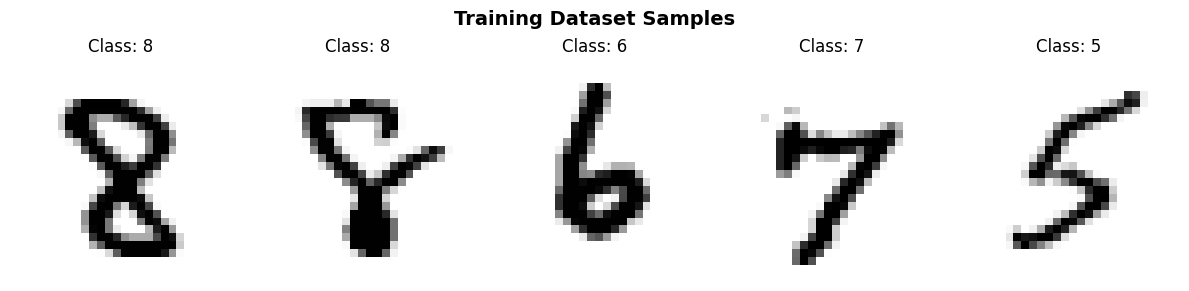

Sample visualization completed

DATA PREPROCESSING INITIATED
Pixel normalization completed
New value range: 0.0 to 1.0
Data reshaping completed: (60000, 28, 28, 1)
Label conversion to categorical format completed

CONSTRUCTING NEURAL NETWORK ARCHITECTURE
Network architecture finalized and compiled
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 26, 26, 32)        320       
                                                                 
 pool1 (MaxPooling2D)        (None, 13, 13, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 11, 11, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 5, 5, 64)          0         
                                                                 
 conv3 (Conv2D)      

In [1]:
# =============================================================================
# DIGIT RECOGNITION MODEL TRAINING SCRIPT
# =============================================================================

# Essential imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Display versions for compatibility check
print("Environment Setup Complete")
print("TensorFlow Version:", tf.__version__)

# =============================================================================
# DATA ACQUISITION PHASE
# =============================================================================

# Load the standard MNIST handwritten digits dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("\n" + "="*50)
print("DATASET LOADED SUCCESSFULLY")
print("="*50)

# Dataset properties examination
print("\nDATASET PROPERTIES:")
print("-" * 30)
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
print(f"Image Dimensions: {X_train.shape[1:]}")

print(f"\nAvailable Classes: {np.unique(y_train)}")
print(f"Intensity Range: {X_train.min()} to {X_train.max()}")

# =============================================================================
# DATA VISUALIZATION
# =============================================================================

# Display sample images from the training set
sample_fig, sample_axes = plt.subplots(1, 5, figsize=(12, 3))
sample_fig.suptitle("Training Dataset Samples", fontsize=14, weight='bold')

random_indices = np.random.choice(len(X_train), 5, replace=False)

for idx, sample_idx in enumerate(random_indices):
    sample_axes[idx].imshow(X_train[sample_idx], cmap='binary')
    sample_axes[idx].set_title(f"Class: {y_train[sample_idx]}")
    sample_axes[idx].axis('off')

plt.tight_layout()
plt.savefig("training_samples.png", dpi=120, bbox_inches='tight')
plt.show()

print("Sample visualization completed")

# =============================================================================
# DATA PREPARATION
# =============================================================================

print("\nDATA PREPROCESSING INITIATED")
print("="*50)

# Normalize pixel values to 0-1 range
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print("Pixel normalization completed")
print(f"New value range: {X_train_normalized.min():.1f} to {X_train_normalized.max():.1f}")

# Reshape data for convolutional network input
X_train_reshaped = X_train_normalized.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test_normalized.reshape(-1, 28, 28, 1)

print(f"Data reshaping completed: {X_train_reshaped.shape}")

# Convert labels to categorical format
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

print("Label conversion to categorical format completed")

# =============================================================================
# NEURAL NETWORK ARCHITECTURE
# =============================================================================

print("\nCONSTRUCTING NEURAL NETWORK ARCHITECTURE")
print("="*50)

# Define the CNN architecture
classification_model = Sequential([
    # First convolutional block
    Conv2D(32, kernel_size=(3, 3), activation='relu', 
           input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D(pool_size=(2, 2), name='pool1'),
    
    # Second convolutional block  
    Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2'),
    MaxPooling2D(pool_size=(2, 2), name='pool2'),
    
    # Third convolutional layer
    Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv3'),
    
    # Classification layers
    Flatten(name='flatten'),
    Dense(64, activation='relu', name='dense1'),
    Dense(10, activation='softmax', name='output')
])

# Compile the model with appropriate settings
classification_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Network architecture finalized and compiled")

# Display model architecture
classification_model.summary()

# =============================================================================
# MODEL TRAINING
# =============================================================================

print("\nTRAINING PROCESS INITIATED")
print("="*50)

# Train the model on the prepared data
training_history = classification_model.fit(
    X_train_reshaped,
    y_train_categorical,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

print("Training phase completed successfully")

# =============================================================================
# PERFORMANCE EVALUATION
# =============================================================================

# Assess model performance on test dataset
test_performance = classification_model.evaluate(X_test_reshaped, y_test_categorical, verbose=0)

print("\nMODEL PERFORMANCE METRICS:")
print("-" * 25)
print(f"Test Accuracy: {test_performance[1] * 100:.2f}%")
print(f"Test Loss: {test_performance[0]:.4f}")

# =============================================================================
# MODEL PERSISTENCE
# =============================================================================

# Save the trained model for future use
classification_model.save("digit_model.keras")

print("\n" + "="*50)
print("MODEL SUCCESSFULLY SAVED AS: digit_model.keras")
print("="*50)